In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt



df = pd.read_csv("data/dataset-merged-2.csv")

display(df)

,Datum,Monat,Tag,Restaurant,Terrasse,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre),Tagesumsatz Restaurant
0,2021-01-01,Januar,Fr,1620.2,0.0,1,1.0,1.0,0.6,0.0,1.7,6852.12,1620.2
1,2021-01-02,Januar,Sa,872.9,0.0,1,1.0,0.0,0.0,0.0,1.5,6852.12,872.9
2,2021-01-03,Januar,So,0.0,0.0,0,1.0,0.0,0.0,0.0,0.5,6852.12,0.0
3,2021-01-04,Januar,Mo,636.2,0.0,0,1.0,0.0,0.0,0.0,0.1,6852.12,636.2
4,2021-01-05,Januar,Di,694.5,0.0,0,1.0,0.0,0.0,0.0,-0.2,6852.12,694.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,2025-11-12,November,Mi,6279.9,362.6,0,0.0,0.0,0.0,419.0,6.2,6225.59,6642.5
1723,2025-11-13,November,Do,6735.1,307.4,0,0.0,0.0,0.0,426.0,8.1,6225.59,7042.5
1724,2025-11-14,November,Fr,12458.5,80.0,1,0.0,0.0,0.0,113.0,9.2,6225.59,12538.5
1725,2025-11-15,November,Sa,15362.0,1909.4,1,0.0,0.0,0.0,396.0,12.0,6225.59,17271.4


Train size: (1408, 11)
Test size : (289, 11)
Train MAE: 1652.85
Test MAE: 2702.86
MSE        : 13115245.82
RMSE       : 3621.50
R²         : 0.6525
MAE        : 2702.86
Relative MSE : 0.3563
MAPE         : 23.12%


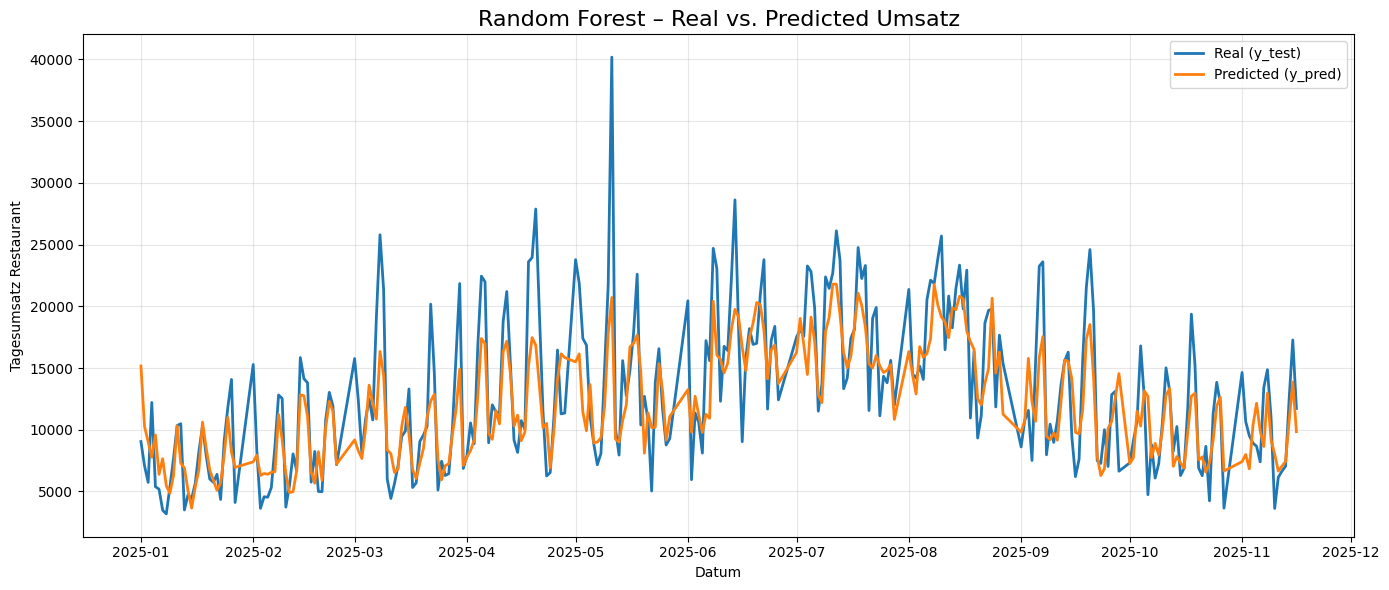

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt



# Datum konvertieren & sortieren
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")
df=df.drop(columns=["Restaurant", "Terrasse"])

# 2) Zielvariable definieren
target = "Tagesumsatz Restaurant"

# 3) Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

# Lags erzeugen NaN → entfernen
df = df.dropna().reset_index(drop=True)

# 4) Feature-Auswahl
num_cols = df.select_dtypes(include=["number"]).columns

feature_cols = [c for c in num_cols if c != target]

X = df[feature_cols]
y = df[target]

# 5) Zeitbasiertes Train/Test-Split
split_date = pd.Timestamp("2025-01-01")

train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# 6) Standardisierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf = RandomForestRegressor(
    n_estimators=300,      # number of trees in the forest; more trees = stabler but slower
    max_features="sqrt",   # number of features to consider when splitting each node ("sqrt" = √ of total)
    max_depth=15,          # limit on tree depth; prevents trees from growing too deep and overfitting
    min_samples_leaf=5,    # minimum number of samples required in a leaf node; larger = smoother predictions
    random_state=72        # seed for reproducibility; ensures the same results each time you run it
)

rf.fit(X_train, y_train)

# Compute the predictions on the training and test sets for logs data
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)


print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test_rf):.2f}")

# MSE, RMSE, R², MAE auf Testset
mse = mean_squared_error(y_test, y_pred_test_rf)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_test_rf)
mae = mean_absolute_error(y_test, y_pred_test_rf)

# Relative MSE (gegen naive Lag-1-Vorhersage)
y_naive = df.loc[test_mask, "lag1"].values      # naive Prognose = Vortag
# (sollte gleiche Länge wie y_test haben)
mse_model = mean_squared_error(y_test, y_pred_test_rf)
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse_model / mse_naive

# MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred_test_rf)

print(f"MSE        : {mse:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R²         : {r2:.4f}")
print(f"MAE        : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

#Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_test_rf, label="Predicted (y_pred)", linewidth=2)

plt.title("Random Forest – Real vs. Predicted Umsatz", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Train MAE: 1627.19
Test MAE: 2521.10
MSE          : 11391750.39
RMSE         : 3375.17
R²           : 0.6982
MAE          : 2521.10
Relative MSE : 0.3094
MAPE         : 21.63%


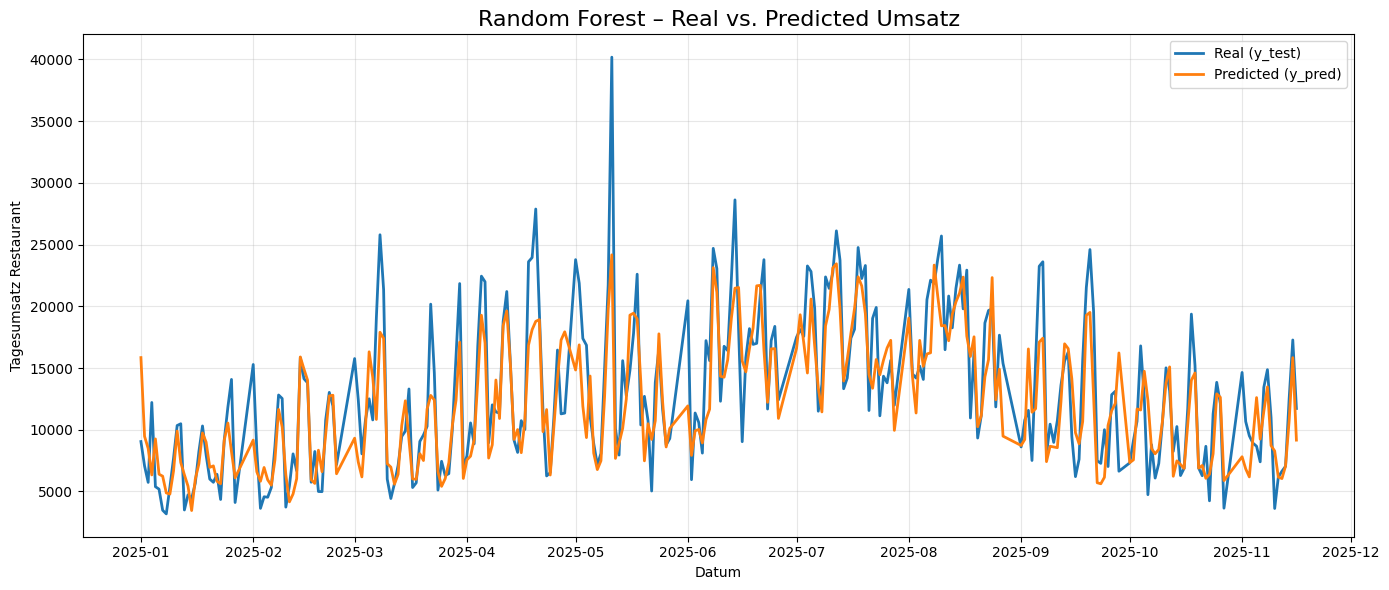

In [5]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(
    learning_rate=0.05,       # how much each tree contributes to the final prediction (smaller = slower, safer learning)
    max_leaf_nodes=30,        # maximum number of leaves per tree; controls tree complexity
    min_samples_leaf=20,      # minimum samples per leaf; larger = more regularization and smoother model
    early_stopping=True,      # stop training early if validation score stops improving
    n_iter_no_change=20,      # number of rounds with no improvement before stopping
    validation_fraction=0.2,  # fraction of training data set aside internally for early stopping
    random_state=72,          # seed for reproducibility
    verbose=0                 # prints progress information while fitting (useful for teaching/demo)
)

gb.fit(X_train, y_train)

# Compute the predictions on the training and test sets for logs data
y_pred_train_gb = gb.predict(X_train)
y_pred_test_gb = gb.predict(X_test)


print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_gb):.2f}")
print(f"Test MAE: { mean_absolute_error(y_test, y_pred_test_gb):.2f}")

# Basic metrics
mse = mean_squared_error(y_test, y_pred_test_gb)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_test_gb)
mae = mean_absolute_error(y_test, y_pred_test_gb)

# --- Relative MSE (vs. naive lag-1 baseline) ---
y_naive = df.loc[test_mask, "lag1"].values   # naive forecast: yesterday's value
mse_model = mean_squared_error(y_test, y_pred_test_gb)
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse_model / mse_naive

# --- MAPE ---
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, y_pred_test_gb)

# Print block
print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


#Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], y_pred_test_gb, label="Predicted (y_pred)", linewidth=2)

plt.title("Random Forest – Real vs. Predicted Umsatz", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Best MSE on test: 11870929.18687
Test MAE: 2630.81
Best params: {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Best MSE on test: 11870929.18687
MSE          : 11870929.19
RMSE         : 3445.42
R²           : 0.6855
MAE          : 2571.97
Relative MSE : 0.3225
MAPE         : 22.05%


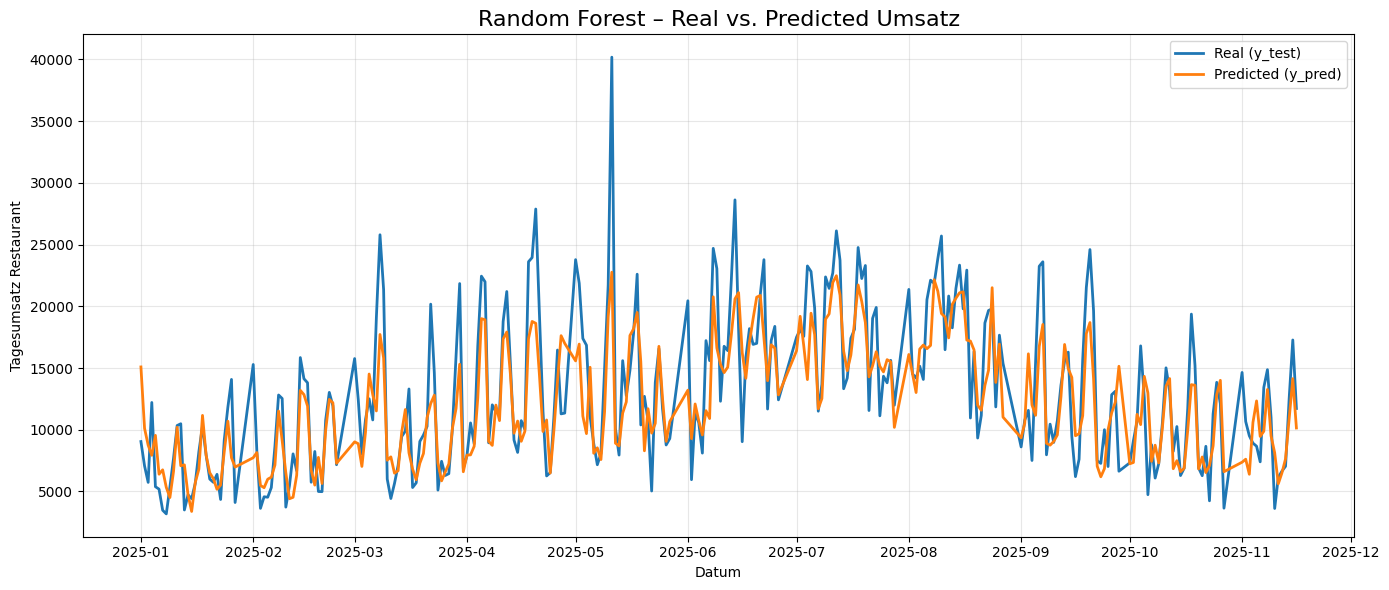

In [6]:
from sklearn.model_selection import ParameterSampler
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# --- Parameter grid for Random Forest ---
param_distributions = {
    "n_estimators": [100, 300],         
    "max_depth": [10, 20, None],        
    "min_samples_leaf": [2, 5],         
    "max_features": ["sqrt", 0.5],      
}

# Sample parameter combinations
n_candidates = 24
candidates = list(ParameterSampler(param_distributions, n_iter=n_candidates, random_state=42))

results = []
mses = []
best = {"mse": np.inf, "params": None, "model": None, "y_pred": None}


# --- Search loop ---
for params in candidates:
    m = RandomForestRegressor(
        random_state=72, **params
    )
    m.fit(X_train, y_train)
    y_pred_test = m.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_test)  # MSE in log space
    mses.append(mse)
    results.append({**params, "mse": mse})

    if mse < best["mse"]:
        best = {"mse": mse, "params": params, "model": m, "y_pred": y_pred_test}

# --- Collect results ---
results_df = pd.DataFrame(results).sort_values("mse", ascending=True)

best_params = best["params"]
best_mse = best["mse"]
best_model = best["model"]
best_y_pred_test = best["y_pred"]


# --- Display results ---
print("Best params:", best_params)
print("Best MSE on test:", round(best_mse, 6))
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")

# basic metrics
mse = mean_squared_error(y_test, best_y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test, best_y_pred_test)
mae = mean_absolute_error(y_test, best_y_pred_test)

# Relative MSE vs naive lag-1 baseline (assumes df + test_mask + 'lag1' exist)
y_naive = df.loc[test_mask, "lag1"].values
mse_naive = mean_squared_error(y_test, y_naive)
relative_MSE = mse / mse_naive

# MAPE
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test, best_y_pred_test)

# --- Display results ---
print("Best params:", best_params)
print("Best MSE on test:", round(best_mse, 6))

print(f"MSE          : {mse:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"MAE          : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")


#Plot the results
plt.figure(figsize=(14,6))
plt.plot(df.loc[test_mask, "Datum"], y_test, label="Real (y_test)", linewidth=2)
plt.plot(df.loc[test_mask, "Datum"], best_y_pred_test, label="Predicted (y_pred)", linewidth=2)

plt.title("Random Forest – Real vs. Predicted Umsatz", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Tagesumsatz Restaurant")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()